# HOMEWORK 9

In [195]:
# added imports
import cv2
import numpy as np
from matplotlib import pyplot as plt
import dlib
import random
plt.rcParams['figure.figsize'] = [15, 10]

In [221]:
def process_img(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #plt.imshow(gray)
    return img, gray

def detect_faces_by_viola_jones(img, gray):
    # load the Viola-Jones detector based on Haar cascades.
    casc_path = '/opt/anaconda3/lib/python3.12/site-packages/cv2/data/haarcascade_frontalface_default.xml'
    face_cascade = cv2.CascadeClassifier(casc_path)

    # faces detection
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=10, flags=cv2.CASCADE_SCALE_IMAGE)
    print('Number of detected faces (Viola-Jones detector based on Haar cascades):', len(faces))

    result = np.copy(img)
    # Draw green rectangles
    for (x, y, w, h) in faces:
        cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 5)
    return result

In [199]:
def detect_rects(gray):
    # Let's load the detector
    detector = dlib.get_frontal_face_detector()
    # Detect faces, see http://dlib.net/face_detector.py.html
    # 1 --> upsampling factor
    rects = detector(gray, 1)

    print('Number of detected faces (dlib):', len(rects))
    #print(rects)
    #print(rects[0].left)
    return rects

def rect_to_bb(rect):
    # Dlib rect --> OpenCV rect
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y

    return (x, y, w, h)

def draw_rectangles(img, rects):
    # Draw rectangle around each faces
    result_dlib = np.copy(img)
    faces_dlib_img = []
    for rect in rects:    
        # Draw rectangle around the face
        x, y, w, h = rect_to_bb(rect)
        #print(x, y, w, h)
        cv2.rectangle(result_dlib, (x, y), (x+w, y+h), (0, 255, 0), 5)

    return result_dlib

def dlib_detection(img, gray):
    rects = detect_rects(gray)
    return draw_rectangles(img, rects)

Number of detected faces (Viola-Jones detector based on Haar cascades): 21
Number of detected faces (dlib): 17


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

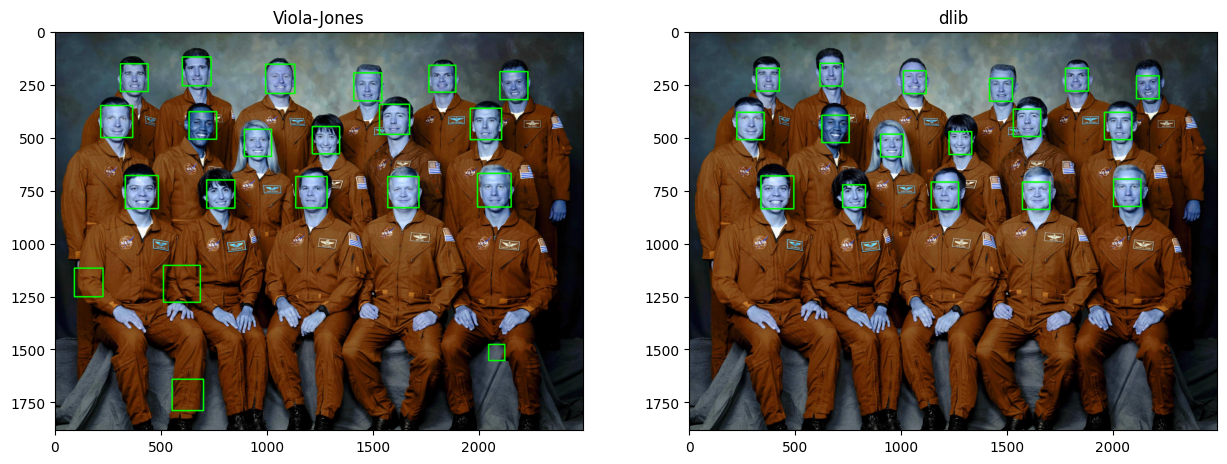

In [201]:
img, gray = process_img('data/nasa.jpg')
result = detect_faces_by_viola_jones(img, gray)
result_dlib = dlib_detection(img, gray)

plt.subplot(121), plt.imshow(result), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 18
Number of detected faces (dlib): 23


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

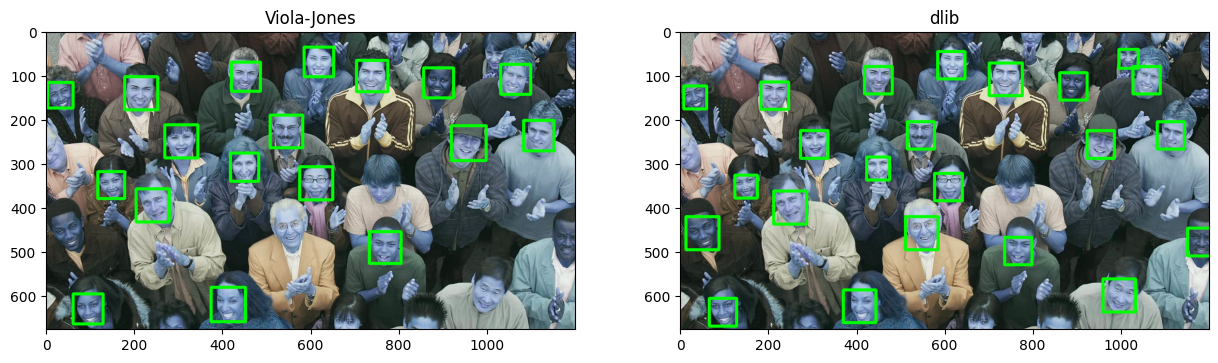

In [203]:
img_2, gray_2 = process_img('data/peoples_2.jpg')
result_2 = detect_faces_by_viola_jones(img_2, gray_2)
result_dlib_2 = dlib_detection(img_2, gray_2)

plt.subplot(121), plt.imshow(result_2), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_2), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 1
Number of detected faces (dlib): 1


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

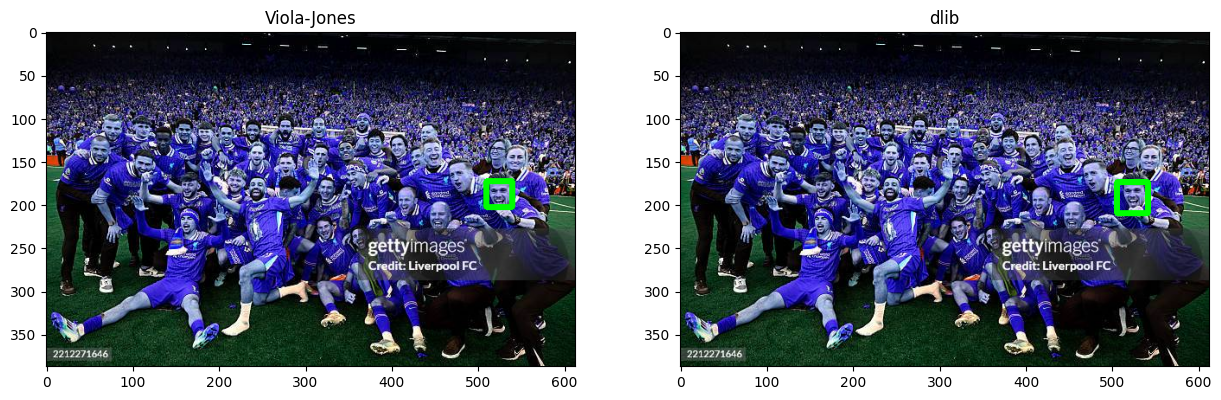

In [205]:
img_3, gray_3 = process_img('data/liverpool.jpg')
result_3 = detect_faces_by_viola_jones(img_3, gray_3)
result_dlib_3 = dlib_detection(img_3, gray_3)

plt.subplot(121), plt.imshow(result_3), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_3), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 3
Number of detected faces (dlib): 5


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

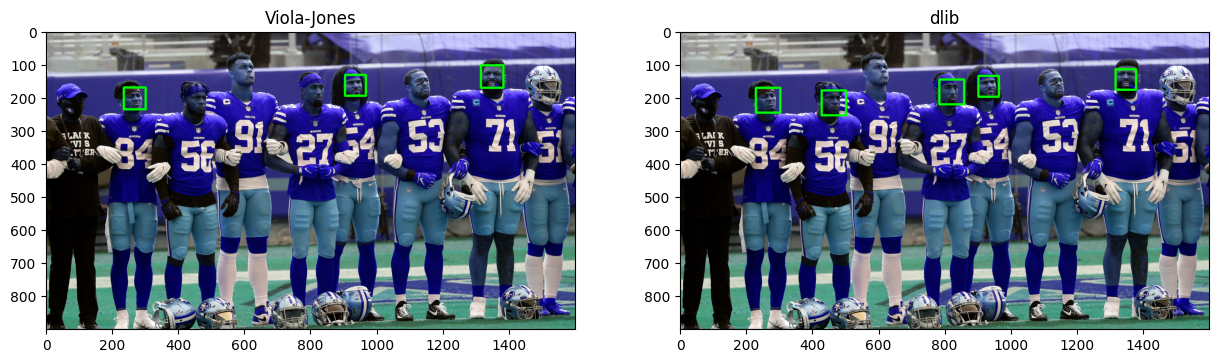

In [207]:
img_4, gray_4 = process_img('data/american_football.jpg')
result_4 = detect_faces_by_viola_jones(img_4, gray_4)
result_dlib_4 = dlib_detection(img_4, gray_4)

plt.subplot(121), plt.imshow(result_4), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_4), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 17
Number of detected faces (dlib): 12


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

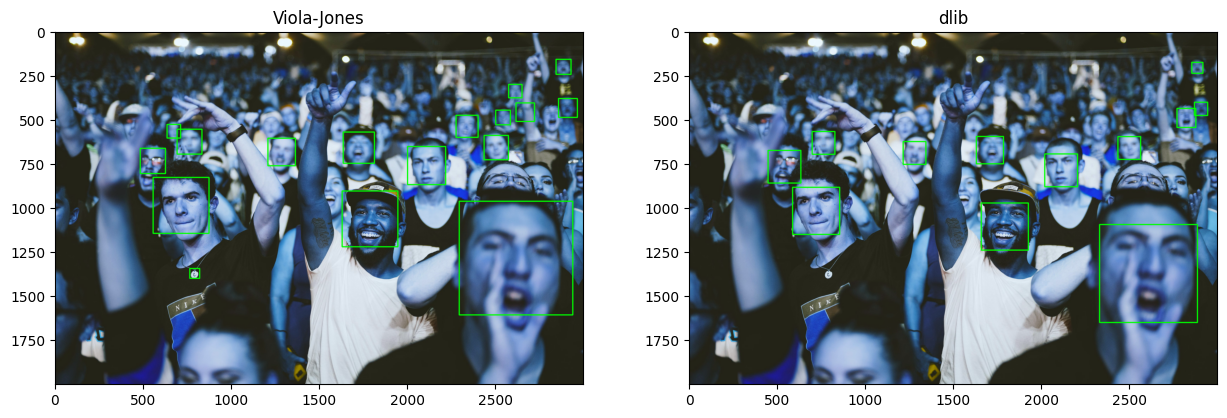

In [209]:
img_5, gray_5 = process_img('data/rock.jpeg')
result_5 = detect_faces_by_viola_jones(img_5, gray_5)
result_dlib_5 = dlib_detection(img_5, gray_5)

plt.subplot(121), plt.imshow(result_5), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_5), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 0
Number of detected faces (dlib): 1


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

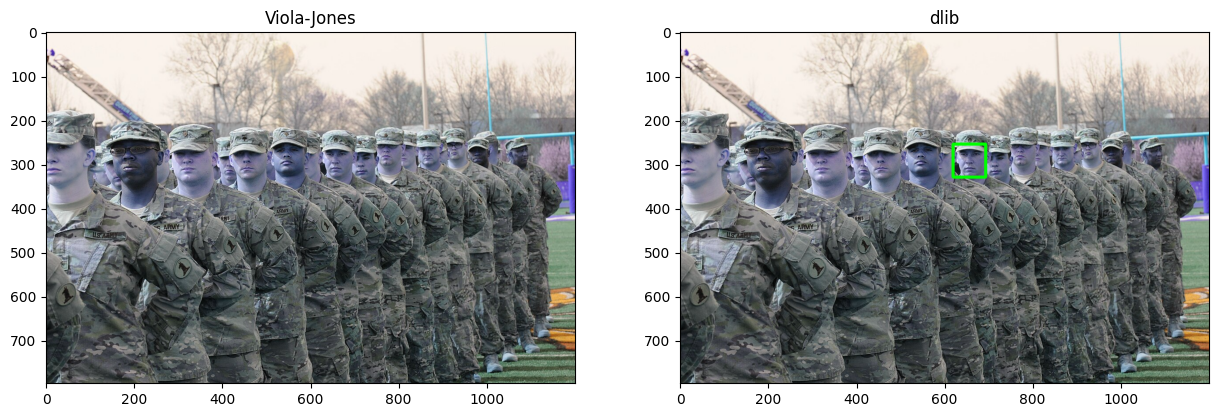

In [211]:
img_6, gray_6 = process_img('data/military.jpg')
result_6 = detect_faces_by_viola_jones(img_6, gray_6)
result_dlib_6 = dlib_detection(img_6, gray_6)

plt.subplot(121), plt.imshow(result_6), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_6), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 13
Number of detected faces (dlib): 5


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

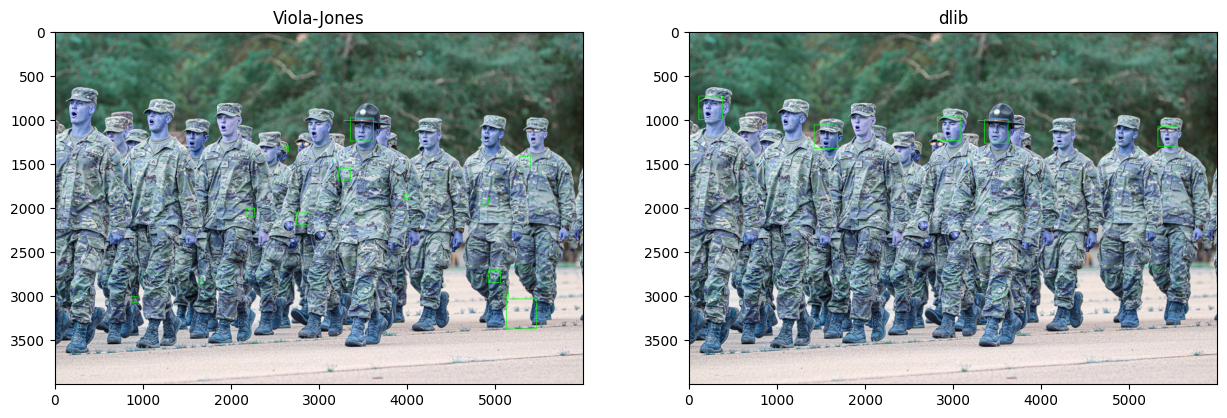

In [223]:
img_7, gray_7 = process_img('data/military_2.jpg')
result_7 = detect_faces_by_viola_jones(img_7, gray_7)
result_dlib_7 = dlib_detection(img_7, gray_7)

plt.subplot(121), plt.imshow(result_7), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_7), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 1
Number of detected faces (dlib): 0


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

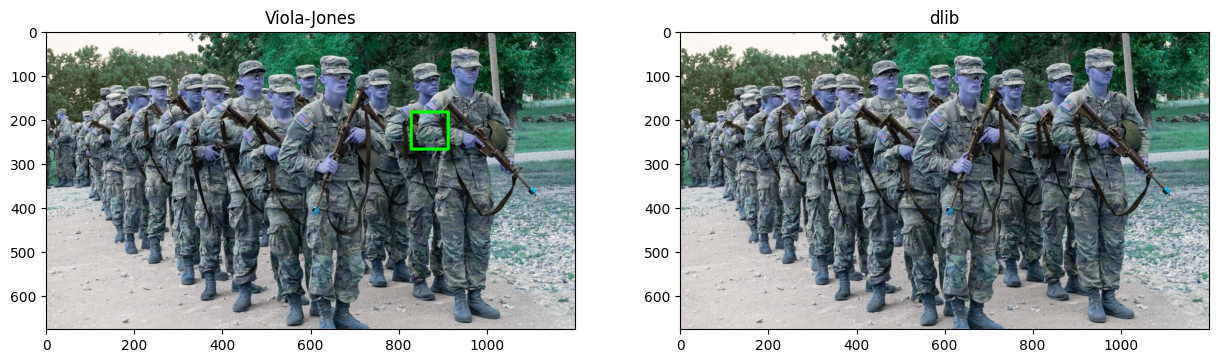

In [227]:
img_8, gray_8 = process_img('data/military_3.jpeg')
result_8 = detect_faces_by_viola_jones(img_8, gray_8)
result_dlib_8 = dlib_detection(img_8, gray_8)

plt.subplot(121), plt.imshow(result_8), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_8), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 5
Number of detected faces (dlib): 4


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

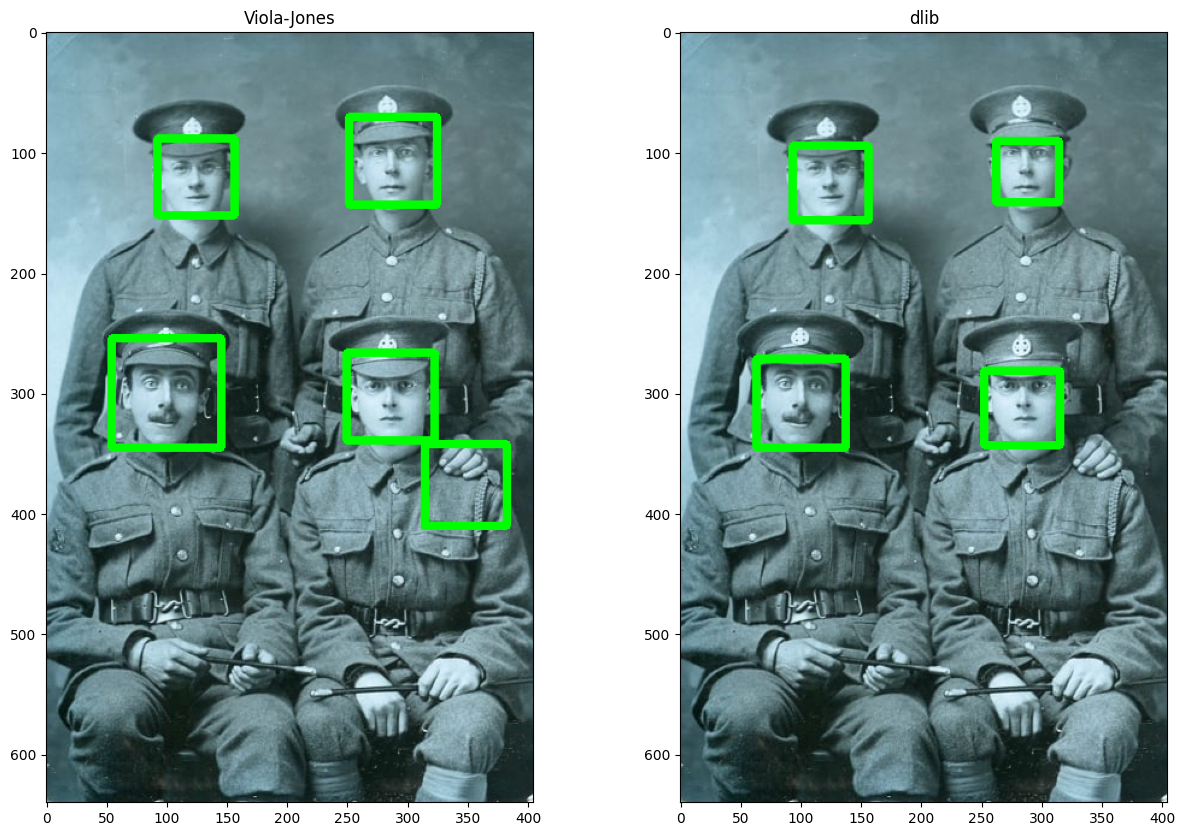

In [235]:
img_9, gray_9 = process_img('data/military_4.jpg')
result_9 = detect_faces_by_viola_jones(img_9, gray_9)
result_dlib_9 = dlib_detection(img_9, gray_9)

plt.subplot(121), plt.imshow(result_9), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_9), plt.title('dlib')

Number of detected faces (Viola-Jones detector based on Haar cascades): 3
Number of detected faces (dlib): 4


(<Axes: title={'center': 'dlib'}>,
 Text(0.5, 1.0, 'dlib'))

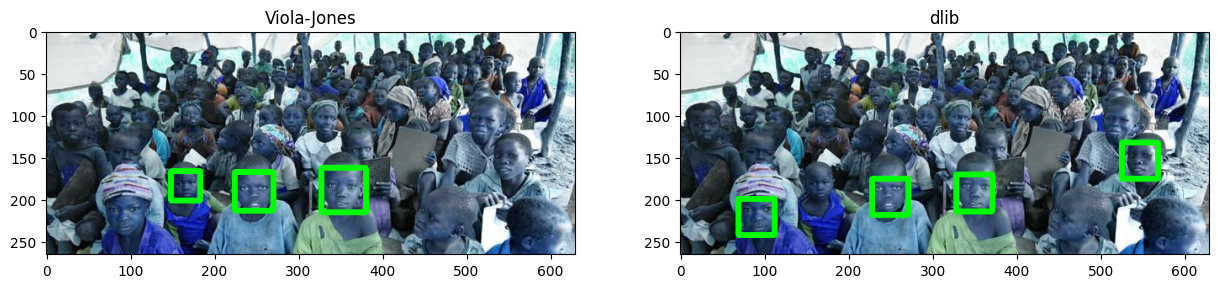

In [237]:
img_10, gray_10 = process_img('data/children.jpg')
result_10 = detect_faces_by_viola_jones(img_10, gray_10)
result_dlib_10 = dlib_detection(img_10, gray_10)

plt.subplot(121), plt.imshow(result_10), plt.title('Viola-Jones')
plt.subplot(122), plt.imshow(result_dlib_10), plt.title('dlib')

(<matplotlib.image.AxesImage at 0x131c36300>,
 Text(0.5, 1.0, 'DNN Face Detection'))

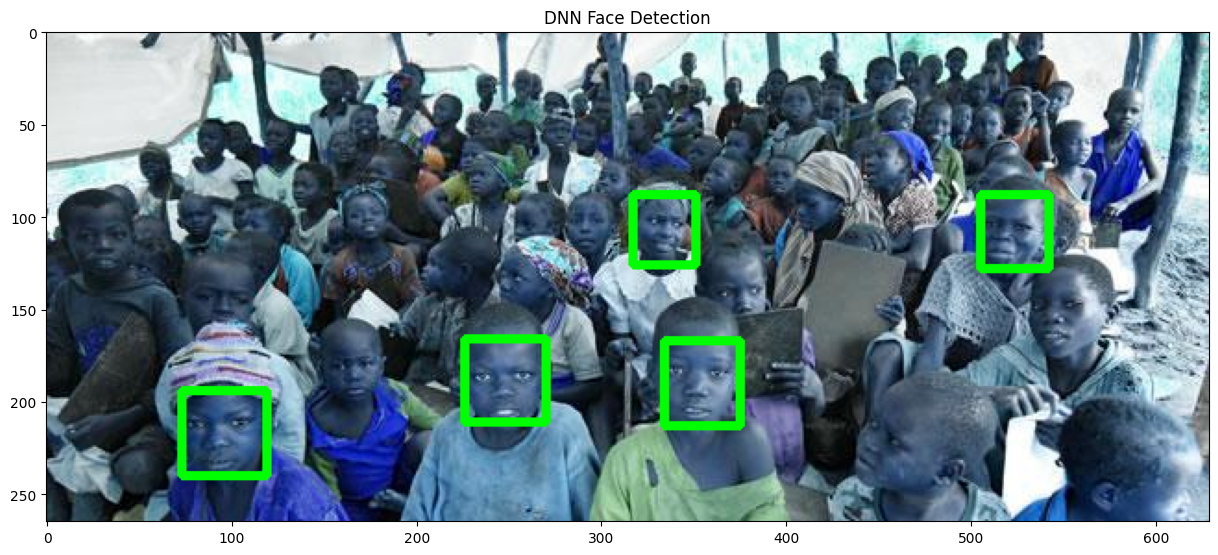

In [242]:
import cv2

# load Caffe model
net = cv2.dnn.readNetFromCaffe(
    "data/deploy.prototxt",
    "data/res10_300x300_ssd_iter_140000.caffemodel"
)

#image = cv2.imread("data/liverpool.jpg")
#image = cv2.imread("data/american_football.jpg")
#image = cv2.imread("data/nasa.jpg")
#image = cv2.imread("data/rock.jpeg")
#image = cv2.imread("data/military_2.jpg")
image = cv2.imread("data/children.jpg")
(h, w) = image.shape[:2]

# make blob
blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
net.setInput(blob)
detections = net.forward()

for i in range(0, detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence > 0.3:  # reliability threshold
        box = detections[0, 0, i, 3:7] * [w, h, w, h]
        (x1, y1, x2, y2) = box.astype("int")
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.imshow(image), plt.title("DNN Face Detection")

Dlib face detector кращий ніж Viola–Jones детектор. Але вони обидва погано працюють з малими обличчями.
Для простих задач можна використовувати Viola–Jones детектор
Для реалістичніших задач краще використовувати Dlib face детектор